# **MLP predictor for ECH index**

Here's an outline of what I want to do:
 - Download the data for ECH from Yahoo Finance, just as they do in the paper, for the same time span and 6 fundamental indicators.
 - Preprocess the data like the paper does
 - Assign a class with a thresholded signal function:
+1 if the next open-to-open move is above the threshold, -1 if it is below the negative threshold, and 0 otherwise.
 - Compute the extra technical indicators using Pandas TA
 - Clean and normalise the dataset. Careful not to normalise the class of course.
 - Calculate the Pearson correlation between each technical indicator and the class.
 - Select the top 10 indicators according to the highest correlation scores. This set will be called "top_10". Make a list of them and print it.
 - Use the top_10 set to train an MLP neural network in a 10-fold cross-validation setup.
 - Assess the accruacy of the MLP model with every partition and find the average accurace across all 10 folds. Report this as the average accuracy of the MLP model.
 - Produce graphs and tables that visualise our resutls and the information we have used and obtained.

Things that I have pending to do:

- ☐ Download the data with _download_history_Polygon.py_ and load it from the local store (ArcticDB) rather than using yfinance

- ☑ Use "Adj Close" or create an "Adj Open", rather than "Open" for Signal – "Open" deosn't consider splits (nor dividends).

- ☑ Fix the scaling/normalisation to happen in the MLP call and not before – ie avoid lookahead bias because of prior scaling knowing future data.

- ☑ Use different Signal function: {+1,0}, {+1,0,-1}, {+1,-1}, {0,-1}. 
See which one makes stronger returns. Here we research the {+1,0,-1} signal function with different `signal_threshold` values delimiting signal 0.

- ☑ When using k-fold CV, try time-series k-fold as well as shuffled.

- ☑ Test different feature-selection scoring functions. Currently testing Pearson correlation (`pearson_score`), after having used/tested ANOVA F-statistics (`f_classif`) and Mutual information (`mutual_info_classif`).

- ☐ The paper used some specifications for the MLP. Understand them and test whether they would improve the performance.

- ☐ Use PCA for selection of principal components to train the MLP.


<!-- 
- ☐ pending task
- ☑ completed task
 -->

Important: whenever I move this idea to a strategy script, the script must be wirtten in the Bluegrey style to facilitate sharing.

### ---- Initialisation ----

In [1]:
# ======================================
# Initialisation -- import libraries
# ======================================

# Core
import numpy as np
import pandas as pd
import time

# Data download
import yfinance as yf

# Technical indicators
# !pip install pandas-ta   # May need to install it first   ------ IGNORE FOR PYTHON 3.11 ------
# !pip install pandas-ta-classic --quiet   # May need to install this too
# !pip install TA-Lib --quiet     # May need to install this too
# import pandas_ta as ta                                  # ------ IGNORE FOR PYTHON 3.11 ------
import pandas_ta_classic as ta

# Machine learning
from sklearn.model_selection import TimeSeriesSplit, KFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif, mutual_info_classif

# Feature analysis
from scipy.stats import pearsonr

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Plot style (publication-like, clean)
sns.set_theme(style="darkgrid", context="talk")

### ---- Download data ----

In [4]:
# =========================
# Download ECH data
# =========================

# Specify ticker and time frame
ticker = "EWZ"
start_date = "2008-01-01"
end_date = "2020-01-01"

# Download data from Yahoo Finance
df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True
    # actions=True
)

# Since we only download one ETF, remove unnecessary Ticker MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close", "Volume"]].copy()

# Visualise the data
print("\n", "Data shape:", df.shape)
display(df)

[*********************100%***********************]  1 of 1 completed


 Data shape: (3021, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2008-01-02,37.233721,37.279127,36.375530,36.756947,15429200
2008-01-03,36.784217,37.092985,36.602589,36.602589,8064600
2008-01-04,36.098563,36.148511,35.045120,35.417458,13878100
2008-01-07,35.376590,35.599083,34.214169,35.081444,16179000
2008-01-08,35.848818,36.470895,34.940678,35.076900,16632700
...,...,...,...,...,...
2019-12-24,30.786617,30.819571,30.681161,30.753662,2671200
2019-12-26,30.997532,31.432539,30.997532,31.432539,18172400
2019-12-27,31.327076,31.373213,31.096392,31.182076,19300700


### ---- Price history plot ----

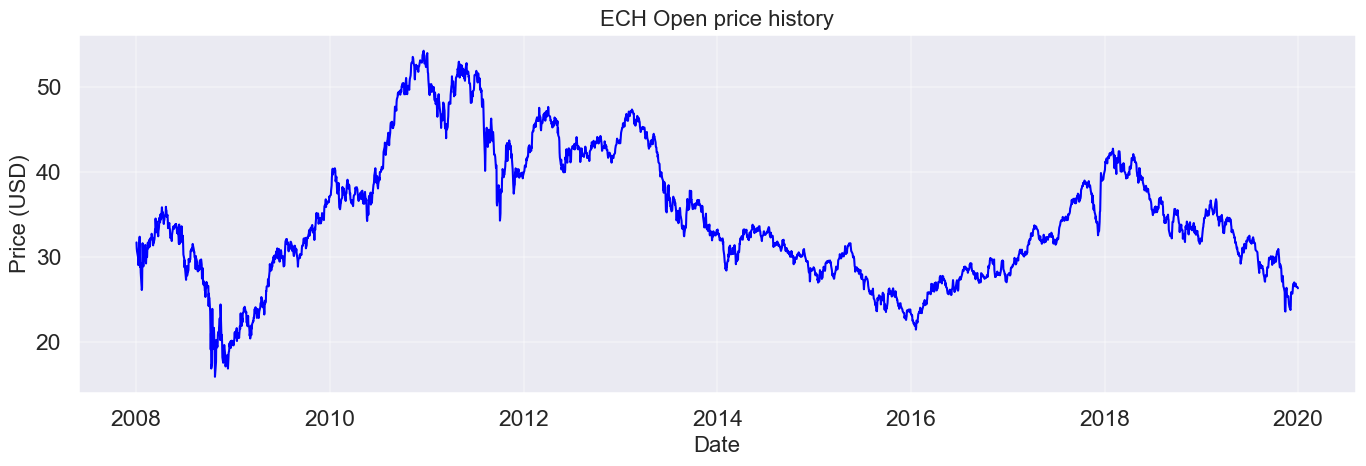

In [344]:
# ==============================================
# Plot ECH price history
# ==============================================

# Plot Open price
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Open'], color='blue', linewidth=1.5)
plt.title(f'{ticker} Open price history', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Price (USD)', fontsize=16)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### ---- Assign signal ----

Assign a signal to each day of data.

At the end of each day $t$ I know all the OHLCV for that day. With this data, I then want the model to predict whether $O_{t+2} - O_{t+1}$ is meaningfully positive, meaningfully negative, or inside a neutral band, since I will position at the $O_{t+1}$ and it is then that I want to know how the price will move. So,

\begin{equation}
\text{Signal }_t =
\begin{cases}
+1, & \text{if } \text{Open }_{t+2} - \text{Open }_{t+1} > \text{threshold} \\
-1, & \text{if } \text{Open }_{t+2} - \text{Open }_{t+1} < -\text{threshold} \\
0, & \text{otherwise}
\end{cases}
\end{equation}
The signal tells us whether the position opened just before $\text{Open }_{t+1}$ should be long (+1), short (-1), or neutral (0).

##### ########## **STRONG CAVEAT** ########## ##########
This model makes a prediction after the close of day $t$, for trading at or before $\text{Open}_{t+1}$.

It is not valid if the model is supposed to predict during or before day $t$, because features (like `BOP`) use $\text{Close}_t$, $\text{High}_t$, and $\text{Low}_t$ to be calculated – all of which are recorded after the market closes.

In [345]:
# =========================
# Assign signal
# =========================

signal_threshold_list = [
    0.0000,  # 0  0.00%
    0.0005,  # 1  0.05%
    0.0010,  # 2  0.10%
    0.0015,  # 3  0.15%
    0.0020,  # 4  0.20%
    0.0030,  # 5  0.30%
    0.0040,  # 6  0.40%
    0.0050,  # 7  0.50%
    0.0075,  # 8  0.75%
    0.0100,  # 9  1.00%
    0.0125,  # 10 1.25%
    0.0150,  # 11 1.50%
    0.0175,  # 12 1.75%
    0.0200,  # 13 2.00%
]

# Signal threshold in log-return units
signal_threshold = signal_threshold_list[13]  # Change this index to select different thresholds

# Compute next days' Open
df["Open_t+1"] = df["Open"].shift(-1)
df["Open_t+2"] = df["Open"].shift(-2)

# Assign signal from the next open-to-open move
open_return = np.log( (df["Open_t+2"] / df["Open_t+1"]) )
df["Signal"] = np.select(
    [open_return > signal_threshold, open_return < -signal_threshold],
    [1, -1],
    default=0
)
df.loc[open_return.isna(), "Signal"] = np.nan

# Cumulative signal  -- sum of signals up to that day
df["Signal_cum"] = df["Signal"].shift(2).cumsum()

# Visualise
# display(df)

##### Cumulative Gamma plot

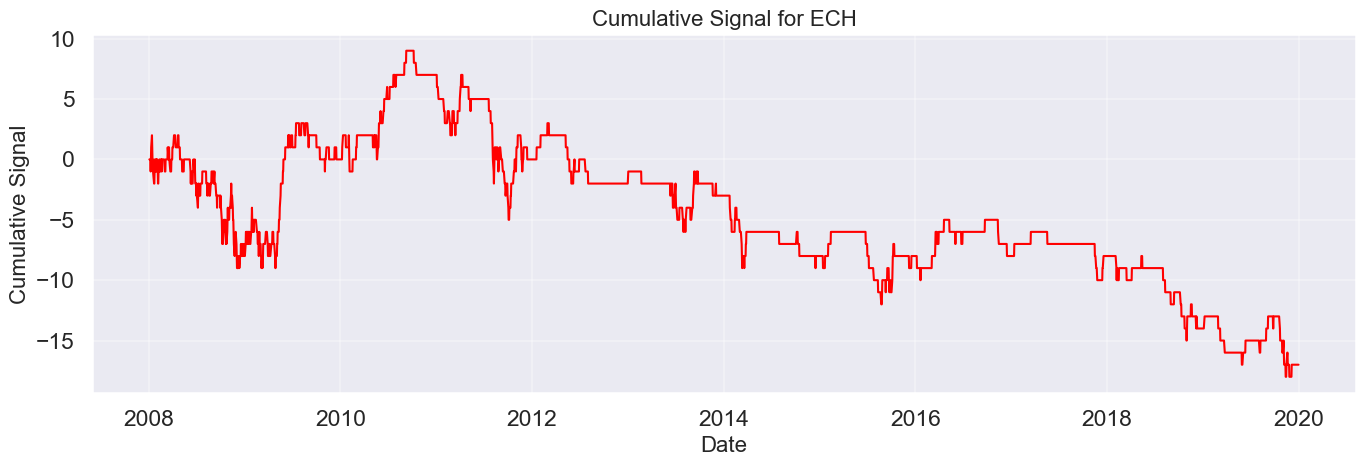

In [346]:
# ==============================================
# Plot Cumultaive Signal
# ==============================================

# Plot the Adjusted prices
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Signal_cum"], color='red', linewidth=1.5)
plt.title(rf'Cumulative Signal for {ticker}', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel(r'Cumulative Signal', fontsize=16)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### ---- Compute technical indicators with Pandas-TA ----

In [347]:
# ==================================================================
# Compute all technical indicators with Pandas-TA and TA-Lib
# ==================================================================

# Run "strategy" to compute and append all available technical indicators.
df.ta.strategy()

# Drop DPO created by df.ta.strategy(), because default DPO may be centered/lookahead-biased
df = df.drop(columns=["DPO_20"], errors="ignore")

# Recompute DPO without lookahead/centering
df.ta.dpo(
    close="Close",
    length=20,
    lookahead=False,
    append=True
)

# Visualise all technical indicators calculated
display(df)

Price,Open,High,Low,Close,Volume,Open_t+1,Open_t+2,Signal,Signal_cum,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,ACOS,AD,ADD,ADOSC_3_10,ADX_14,DMP_14,DMN_14,ADXR_14,ALMA_10_6.0_0.85,AMATe_LR_8_21_2,AMATe_SR_8_21_2,AO_5_34,OBV,OBV_min_2,OBV_max_2,OBVe_4,OBVe_12,AOBV_LR_2,AOBV_SR_2,APO_12_26,AROOND_14,AROONU_14,AROONOSC_14,ASIN,ATAN,ATRr_14,AVGPRICE,AVOLUME_20,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0,BIAS_SMA_26,BOP,AR_26,BR_26,CCI_14_0.015,CDL_DOJI_10_0.1,CDL_INSIDE,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3STARSINSOUTH,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,CDL_BREAKAWAY,CDL_CLOSINGMARUBOZU,CDL_CONCEALBABYSWALL,CDL_COUNTERATTACK,CDL_DARKCLOUDCOVER,CDL_DOJISTAR,CDL_DRAGONFLYDOJI,CDL_ENGULFING,CDL_EVENINGDOJISTAR,CDL_EVENINGSTAR,CDL_GAPSIDESIDEWHITE,CDL_GRAVESTONEDOJI,CDL_HAMMER,CDL_HANGINGMAN,CDL_HARAMI,CDL_HARAMICROSS,CDL_HIGHWAVE,CDL_HIKKAKE,CDL_HIKKAKEMOD,CDL_HOMINGPIGEON,CDL_IDENTICAL3CROWS,CDL_INNECK,CDL_INVERTEDHAMMER,CDL_KICKING,CDL_KICKINGBYLENGTH,CDL_LADDERBOTTOM,CDL_LONGLEGGEDDOJI,CDL_LONGLINE,CDL_MARUBOZU,CDL_MATCHINGLOW,CDL_MATHOLD,CDL_MORNINGDOJISTAR,CDL_MORNINGSTAR,CDL_ONNECK,CDL_PIERCING,CDL_RICKSHAWMAN,CDL_RISEFALL3METHODS,CDL_SEPARATINGLINES,CDL_SHOOTINGSTAR,CDL_SHORTLINE,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,open_Z_30_1,high_Z_30_1,low_Z_30_1,close_Z_30_1,CE_L_22_3.0,CE_S_22_3.0,CEIL,CFO_9,CG_10,CHOP_14_1_100,CKSPl_10_3_20,CKSPs_10_3_20,CMF_20,CMO_14,COPC_11_14_10,COS,COSH,CPR_TC,CPR_PIVOT,CPR_BC,CPR_R1,CPR_R2,CPR_S1,CPR_S2,CPR_WIDTH,CPR_WIDTH_PCT,CPR_WIDTH_CLASS,CPR_POSITION,Close_X_Close,Close_XA_Close,CTI_12,CVI_10,LDECAY_5,DEC_1,DEMA_10,DIV,DCL_20_20,DCM_20_20,DCU_20_20,DD,DD_PCT,DD_LOG,DSP_14,DX_14,EBSW_40_10,EDECAY_5,EFI_13,EMA_10,EMV,ENTP_10,EOM_14_100000000,ER_10,BULLP_13,BEARP_13,EXP,FISHERT_9_1,FISHERTs_9_1,FLOOR,FOSC_14,FWMA_10,HA_open,HA_high,HA_low,HA_close,HILO_13_21,HILOl_13_21,HILOs_13_21,HL2,HLC3,HMA_10,HT_DCPERIOD,HT_DCPHASE,HT_PHASOR_INPHASE,HT_PHASOR_QUAD,HT_SINE,HT_LEADSINE,HT_TRENDLINE,HT_TRENDMODE,HVOL_20,HWM,HWU,HWL,HWMA_0.2_0.1_0.1,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,INC_1,INERTIA_20_14,JMA_7_0,KAMA_10_2_30,KCLe_20_2,KCBe_20_2,KCUe_20_2,K_9_3,D_9_3,J_9_3,KST_10_15_20_30_10_10_10_15,KSTs_9,KURT_30,KVO_34_55_13,KVOs_34_55_13,LAG_1,LR_14,LRa_14,LRb_14,LRm_14,LN,LOG10,LOGRET_1,LRSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,MACDEXT_12_26_9,MACDEXTs_12_26_9,MACDEXTh_12_26_9,MACDFIX_9_9,MACDFIXh_9_9,MACDFIXs_9_9,MAD_30,MAMA_0.5_0.05,FAMA_0.5_0.05,MARKETFI,MASSI_9_25,MAVP_2_30,MAXINDEX_30,MCGD_10,MD_30,MEDIAN_30,MEDPRICE,MFI_14,MIDPOINT_2,MIDPRICE_2,MININDEX_30,MIN_30,MAX_30,MINIDX_30,MAXIDX_30,MINUS_DM_14,MMAR_10,MMAR_15,MMAR_20,MMAR_25,MMAR_30,MMAR_35,MOM_10,MSW_SINE_5,MSW_LEAD_5,MULT,NATR_14,ABS,ROUND,NVI_1,OHLC4,PDIST,PCTRET_1,PGO_14,PLUS_DM_14,PMAX_E_10_3.0,PO_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,PSARl_0.02_0.2,PSARs_0.02_0.2,PSARaf_0.02_0.2,PSARr_0.02_0.2,PSL_12,PVI_1,PVO_12_26_9,PVOh_12_26_9,PVOs_12_26_9,PVOL,PVR,PVT,PWMA_10,QQE_14_5_4.236,QQE_14_5_4.236_RSIMA,QQEl_14_5_4.236,QQEs_14_5_4.236,QQEb_l_14_5_4.236,QQEb_s_14_5_4.236,QQEd_14_5_4.236,QS_10,QTL_30_0.5,RAINBOW_1,RAINBOW_2,RAINBOW_3,RAINBOW_4,RAINBOW_5,RAINBOW_6,RAINBOW_7,RAINBOW_8,RAINBOW_9,RAINBOW_10,RMA_10,ROC_10,ROCP_10,ROCR_10,ROCR100_10,SUM_30,RSI_14,RSX_14,RVGIh_14_4,RVGI_14_4,RVGIs_14_4,RVI_14,SAREXT,SIN,SINH,SINWMA_14,SKEW_30,SLOPE_1,SMA_10,SMI_5_20_5,SMIs_5_20_5,SMIo_5_20_5,SQRT,SQZ_20_2.0_20_1.5,SQZ_ON,SQZ_OFF,SQZ_NO,SQZPRO_20_2.0_20_2_1.5_1,SQZPRO_ON_WIDE,SQZPRO_ON_NORMAL,SQZPRO_ON_NARROW,SQZPRO_OFF,SQZPRO_NO,SSF_10_2,STC_10_12_26_0.5,STCmacd_10_12_26_0.5,STCstoch_10_12_26_0.5,STDERR_14,STDEV_30,STOCHk_14_3_3,STOCHd_14_3_3,STOCHFk_5_3,STOCHFd_5_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,SUB,SUPERT_7_3.0,SUPERTd_7_3.0,SUPERTl_7_3.0,SUPERTs_7_3.0,SWMA_10,T3_10_0.7,TAN,TANH,TEMA_10,THERMO_20_2_0.

In [348]:
# ================================================
# List all column names (technical indicators)
# ================================================

cols = df.columns.tolist()

# Find total number of columns (technical indicators) and how many were added by Pandas-TA
n_total = len(cols)
n_added = n_total - 9  # there were already 9 to start with

# Display all column names
print(cols)
# display(pd.DataFrame({"Column": cols}))

print("\n", f"Total number of technical indicators: {n_total}")
print("\n", f"Added TA columns: {n_added}", "\n")


['Open', 'High', 'Low', 'Close', 'Volume', 'Open_t+1', 'Open_t+2', 'Signal', 'Signal_cum', 'ABER_ZG_5_15', 'ABER_SG_5_15', 'ABER_XG_5_15', 'ABER_ATR_5_15', 'ACCBL_20', 'ACCBM_20', 'ACCBU_20', 'ACOS', 'AD', 'ADD', 'ADOSC_3_10', 'ADX_14', 'DMP_14', 'DMN_14', 'ADXR_14', 'ALMA_10_6.0_0.85', 'AMATe_LR_8_21_2', 'AMATe_SR_8_21_2', 'AO_5_34', 'OBV', 'OBV_min_2', 'OBV_max_2', 'OBVe_4', 'OBVe_12', 'AOBV_LR_2', 'AOBV_SR_2', 'APO_12_26', 'AROOND_14', 'AROONU_14', 'AROONOSC_14', 'ASIN', 'ATAN', 'ATRr_14', 'AVGPRICE', 'AVOLUME_20', 'BBL_5_2.0', 'BBM_5_2.0', 'BBU_5_2.0', 'BBB_5_2.0', 'BBP_5_2.0', 'BIAS_SMA_26', 'BOP', 'AR_26', 'BR_26', 'CCI_14_0.015', 'CDL_DOJI_10_0.1', 'CDL_INSIDE', 'CDL_2CROWS', 'CDL_3BLACKCROWS', 'CDL_3INSIDE', 'CDL_3LINESTRIKE', 'CDL_3OUTSIDE', 'CDL_3STARSINSOUTH', 'CDL_3WHITESOLDIERS', 'CDL_ABANDONEDBABY', 'CDL_ADVANCEBLOCK', 'CDL_BELTHOLD', 'CDL_BREAKAWAY', 'CDL_CLOSINGMARUBOZU', 'CDL_CONCEALBABYSWALL', 'CDL_COUNTERATTACK', 'CDL_DARKCLOUDCOVER', 'CDL_DOJISTAR', 'CDL_DRAGONFLYDO

### ---- Clean data ----

In [349]:
# ===============================================================
# Find what columns have way too many NaNs to remove them
# ===============================================================

# Percentage of NaNs per column
nan_pct = df.isna().mean().copy() * 100

nan_pct.index.name = 'Tech Indicators NaN % (sorted)'
display(nan_pct.sort_values(ascending=False).head(20))

# Scan thresholds from 0% to 60%
for x in [0, 5, 10, 20, 30, 40, 50]:
    cols = nan_pct[nan_pct > x].index.tolist()

    print(f"\n Number of columns with > {x}% NaNs: {len(cols)}")
    # print(cols)       # Uncomment if you want to see names


Tech Indicators NaN % (sorted)
ASIN                 100.000000
ACOS                 100.000000
PSARs_0.02_0.2        53.459119
SUPERTs_7_3.0         53.326713
QQEs_14_5_4.236       53.028798
QQEl_14_5_4.236       49.321417
SUPERTl_7_3.0         46.904998
PSARl_0.02_0.2        46.573982
HILOs_13_21           42.767296
HILOl_13_21           40.383979
VFI_130                8.639523
TRIXs_30_9             3.177756
TRIX_30_9              2.912943
ISB_26                 2.548825
QQE_14_5_4.236         2.350215
QQEb_s_14_5_4.236      2.317114
QQEb_l_14_5_4.236      2.317114
KVOs_34_55_13          2.184707
TRIXs_18_9             1.986097
TRIXh_18_9             1.986097
dtype: float64


 Number of columns with > 0% NaNs: 257

 Number of columns with > 5% NaNs: 11

 Number of columns with > 10% NaNs: 10

 Number of columns with > 20% NaNs: 10

 Number of columns with > 30% NaNs: 10

 Number of columns with > 40% NaNs: 10

 Number of columns with > 50% NaNs: 5


In [350]:
# ==================================================
# NaN percentage scan (columns)
# ==================================================

run_this_cell = False  # Set to True to run the scan
# run_this_cell = True  # Set to True to run the scan

if run_this_cell:

    # Percentage of NaNs per column
    nan_pct = df.isna().mean().copy() * 100

    # Scan thresholds from 0% to 60% in steps of 5%
    for x in range(0, 60, 5):
        cols = nan_pct[nan_pct <= x].index.tolist()

        print(f"\n Number of columns with <= {x}% NaNs: {len(cols)}")
        # Uncomment if you want to see names
        # print(cols)

After inspecting the columns, we decide to remove all columns with more than 5% NaNs. This way we will drop less rows due to NaNs too.

In [351]:
# ==================================================
# Find the maximum number of NaNs allowed per column
# ==================================================

# Max percentage of NaNs allowed in columns
nan_thresh = 0.05

# Calculate threshold - i.e. minimum number of non-NaNs to keep the column
threshold = int((1 - nan_thresh) * df.shape[0])
print(threshold)

2869


We now proceed to remove/clean any columns with too many NaNs, non-numeric columns and the auxiliary 'Open_t+1', 'Open_t+2' and 'Signal_cum' columns.

In [352]:
# ====================================================================================================
# Data cleaning – drop columns and rows with too many NaNs, non-numeric and auxiliary columns
# ====================================================================================================

rows_before_cleaning = df.shape[0]
cols_before_cleaning = df.shape[1]

# Drop columns with too many NaNs (e.g. >5%)
df = df.dropna(thresh=threshold, axis=1).copy()

# Drop rows with NaNs in "Open_t+1" and "Open_t+2"
df = df.dropna(subset=["Open_t+1", "Open_t+2"]).copy()

# Drop auxiliary "Open_t+1", "Open_t+2" and "Signal_cum" columns
df = df.drop(columns=['Open_t+1', 'Open_t+2'], errors='ignore').copy()
df = df.drop(columns=['Signal_cum'], errors='ignore').copy()

# Drop non-numeric columns (if any)
df = df.select_dtypes(include=['number']).copy()

cols_after_cleaning = df.shape[1]
cols_removed = cols_before_cleaning - cols_after_cleaning

# Drop rows with any remaining NaNs
df = df.dropna().copy()

rows_after_cleaning = df.shape[0]
rows_cleaned = rows_before_cleaning - rows_after_cleaning

# Visualise
print("\n", cols_removed, "NaN, non-numeric and auxiliary columns have been removed.")
print(rows_cleaned, "rows with NaN have been cleaned.")
print("\n", "We now have", rows_after_cleaning, "rows and", df.shape[1], "columns (features = OHLCVSc + indicators) in the dataset.", "\n")

# display(df)


 16 NaN, non-numeric and auxiliary columns have been removed.
122 rows with NaN have been cleaned.

 We now have 2899 rows and 399 columns (features = OHLCVSc + indicators) in the dataset. 



Next, we want to remove any columns left that have 0 variance (ie. all values are the same). These don't add any information, and would just dump noise on the model.

In [353]:
# ==================================================
# Diagnose and remove globally constant features
# ==================================================

# Identify columns with only one unique value
global_constant_cols = df.columns[df.nunique(dropna=False) <= 1]

# Report how many constant features were found and their unique values
print(f"\n Number of globally constant features: {len(global_constant_cols)}", "\n They will be removed as they provide no information for ML models.")
if len(global_constant_cols) > 0:
    display(pd.DataFrame({
        "Column": global_constant_cols,
        "Unique values": [df[col].unique() for col in global_constant_cols]
    }))

# Drop constant features
df = df.drop(columns=global_constant_cols).copy()

# Visualise
print("\n", "We now have", rows_after_cleaning, "rows and", df.shape[1], "columns (features = OHLCaCV + indicators) in the dataset.", "\n")

# display(df)


 Number of globally constant features: 14 
 They will be removed as they provide no information for ML models.


,Column,Unique values
0,CDL_3STARSINSOUTH,[0.0]
1,CDL_BREAKAWAY,[0.0]
2,CDL_CONCEALBABYSWALL,[0.0]
3,CDL_IDENTICAL3CROWS,[0.0]
4,CDL_KICKING,[0.0]
5,CDL_KICKINGBYLENGTH,[0.0]
6,CDL_MATHOLD,[0.0]
7,CDL_RISEFALL3METHODS,[0.0]
8,Close_X_Close,[1]
9,Close_XA_Close,[0]



 We now have 2899 rows and 385 columns (features = OHLCaCV + indicators) in the dataset. 



### ---- Walk-forward cross-validation definition ----

Define a function that runs the MLP neural network with 10-fold cross validation and computes the accuracy and computation time for a given number _n_ of top _n_ features.

We ensure there is no lookahead bias by only normalising the data in the training fold for each fold of the process and not beofre giving the data to the model. Moreover, the top _n_ features are selected from the training data and not the whole data.

First, we separate the feature data from the target data.

In [354]:
# =========================
# Feature / target split
# =========================

# Separate features X and target y
X = df.drop(columns=["Signal"]).copy()
y = df["Signal"].copy()

print(f"Feature matrix shape: {X.shape}")
display(X.head(10))
print(f"Target shape: {y.shape}")
display(y.head(10))

Feature matrix shape: (2899, 384)


Price,Open,High,Low,Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,AD,ADD,ADOSC_3_10,ADX_14,DMP_14,DMN_14,ADXR_14,ALMA_10_6.0_0.85,AMATe_LR_8_21_2,AMATe_SR_8_21_2,AO_5_34,OBV,OBV_min_2,OBV_max_2,OBVe_4,OBVe_12,AOBV_LR_2,AOBV_SR_2,APO_12_26,AROOND_14,AROONU_14,AROONOSC_14,ATAN,ATRr_14,AVGPRICE,AVOLUME_20,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0,BIAS_SMA_26,BOP,AR_26,BR_26,CCI_14_0.015,CDL_DOJI_10_0.1,CDL_INSIDE,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,CDL_CLOSINGMARUBOZU,CDL_COUNTERATTACK,CDL_DARKCLOUDCOVER,CDL_DOJISTAR,CDL_DRAGONFLYDOJI,CDL_ENGULFING,CDL_EVENINGDOJISTAR,CDL_EVENINGSTAR,CDL_GAPSIDESIDEWHITE,CDL_GRAVESTONEDOJI,CDL_HAMMER,CDL_HANGINGMAN,CDL_HARAMI,CDL_HARAMICROSS,CDL_HIGHWAVE,CDL_HIKKAKE,CDL_HIKKAKEMOD,CDL_HOMINGPIGEON,CDL_INNECK,CDL_INVERTEDHAMMER,CDL_LADDERBOTTOM,CDL_LONGLEGGEDDOJI,CDL_LONGLINE,CDL_MARUBOZU,CDL_MATCHINGLOW,CDL_MORNINGDOJISTAR,CDL_MORNINGSTAR,CDL_ONNECK,CDL_PIERCING,CDL_RICKSHAWMAN,CDL_SEPARATINGLINES,CDL_SHOOTINGSTAR,CDL_SHORTLINE,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,open_Z_30_1,high_Z_30_1,low_Z_30_1,close_Z_30_1,CE_L_22_3.0,CE_S_22_3.0,CEIL,CFO_9,CG_10,CHOP_14_1_100,CKSPl_10_3_20,CKSPs_10_3_20,CMF_20,CMO_14,COPC_11_14_10,COS,COSH,CPR_TC,CPR_PIVOT,CPR_BC,CPR_R1,CPR_R2,CPR_S1,CPR_S2,CPR_WIDTH,CPR_WIDTH_PCT,CTI_12,CVI_10,LDECAY_5,DEC_1,DEMA_10,DCL_20_20,DCM_20_20,DCU_20_20,DD,DD_PCT,DD_LOG,DSP_14,DX_14,EBSW_40_10,EDECAY_5,EFI_13,EMA_10,EMV,ENTP_10,EOM_14_100000000,ER_10,BULLP_13,BEARP_13,EXP,FISHERT_9_1,FISHERTs_9_1,FLOOR,FOSC_14,FWMA_10,HA_open,HA_high,HA_low,HA_close,HILO_13_21,HL2,HLC3,HMA_10,HT_DCPERIOD,HT_DCPHASE,HT_PHASOR_INPHASE,HT_PHASOR_QUAD,HT_SINE,HT_LEADSINE,HT_TRENDLINE,HT_TRENDMODE,HVOL_20,HWM,HWU,HWL,HWMA_0.2_0.1_0.1,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,INC_1,INERTIA_20_14,JMA_7_0,KAMA_10_2_30,KCLe_20_2,KCBe_20_2,KCUe_20_2,K_9_3,D_9_3,J_9_3,KST_10_15_20_30_10_10_10_15,KSTs_9,KURT_30,KVO_34_55_13,KVOs_34_55_13,LAG_1,LR_14,LRa_14,LRb_14,LRm_14,LN,LOG10,LOGRET_1,LRSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,MACDEXT_12_26_9,MACDEXTs_12_26_9,MACDEXTh_12_26_9,MACDFIX_9_9,MACDFIXh_9_9,MACDFIXs_9_9,MAD_30,MAMA_0.5_0.05,FAMA_0.5_0.05,MARKETFI,MASSI_9_25,MAVP_2_30,MAXINDEX_30,MCGD_10,MD_30,MEDIAN_30,MEDPRICE,MFI_14,MIDPOINT_2,MIDPRICE_2,MININDEX_30,MIN_30,MAX_30,MINIDX_30,MAXIDX_30,MINUS_DM_14,MMAR_10,MMAR_15,MMAR_20,MMAR_25,MMAR_30,MMAR_35,MOM_10,MSW_SINE_5,MSW_LEAD_5,MULT,NATR_14,ABS,ROUND,NVI_1,OHLC4,PDIST,PCTRET_1,PGO_14,PLUS_DM_14,PMAX_E_10_3.0,PO_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,PSARaf_0.02_0.2,PSARr_0.02_0.2,PSL_12,PVI_1,PVO_12_26_9,PVOh_12_26_9,PVOs_12_26_9,PVOL,PVR,PVT,PWMA_10,QQE_14_5_4.236,QQE_14_5_4.236_RSIMA,QQEb_l_14_5_4.236,QQEb_s_14_5_4.236,QQEd_14_5_4.236,QS_10,QTL_30_0.5,RAINBOW_1,RAINBOW_2,RAINBOW_3,RAINBOW_4,RAINBOW_5,RAINBOW_6,RAINBOW_7,RAINBOW_8,RAINBOW_9,RAINBOW_10,RMA_10,ROC_10,ROCP_10,ROCR_10,ROCR100_10,SUM_30,RSI_14,RSX_14,RVGIh_14_4,RVGI_14_4,RVGIs_14_4,RVI_14,SAREXT,SIN,SINH,SINWMA_14,SKEW_30,SLOPE_1,SMA_10,SMI_5_20_5,SMIs_5_20_5,SMIo_5_20_5,SQRT,SQZ_20_2.0_20_1.5,SQZ_ON,SQZ_OFF,SQZPRO_20_2.0_20_2_1.5_1,SQZPRO_ON_WIDE,SQZPRO_ON_NORMAL,SQZPRO_ON_NARROW,SQZPRO_OFF,SSF_10_2,STC_10_12_26_0.5,STCmacd_10_12_26_0.5,STCstoch_10_12_26_0.5,STDERR_14,STDEV_30,STOCHk_14_3_3,STOCHd_14_3_3,STOCHFk_5_3,STOCHFd_5_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,SUPERT_7_3.0,SUPERTd_7_3.0,SWMA_10,T3_10_0.7,TAN,TANH,TEMA_10,THERMO_20_2_0.5,THERMOma_20_2_0.5,THERMOl_20_2_0.5,THERMOs_20_2_0.5,TODEG,TORAD,TOS_STDEVALL_LR,TOS_STDEVALL_L_1,TOS_STDEVALL_U_1,TOS_STDEVALL_L_2,TOS_STDEVALL_U_2,TOS_STDEVALL_L_3,TOS_STDEVALL_U_3,TRIMA_10,TRIX_30_9,TRIXs_30_9,TRIX_18_9,TRIXs_18_9,TRIXh_18_9,TRUERANGE_1,TRUNC,TSF_14,TSI_13_25_13,TSIs_13_25_13,TTM_TRND_6,TYPPRICE,UI_14,UO_7_14_28,VAR_30,VHF_28,VIDYA_14,VTXP_14,VTXM_14,VOSC_14

Target shape: (2899,)


Date
2008-05-20    0.0
2008-05-21    0.0
2008-05-22    0.0
2008-05-23    0.0
2008-05-27    0.0
2008-05-28    0.0
2008-05-29    0.0
2008-05-30    0.0
2008-06-02    0.0
2008-06-03    0.0
Name: Signal, dtype: float64

In [355]:
# ==================================================
# Inspect chronological CV splits
# ==================================================

number_of_folds = 5
tscv = TimeSeriesSplit(n_splits=number_of_folds)

split_info = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    split_info.append({
        "Fold": fold,
        "Train start": X.index[train_idx[0]],
        "Train end": X.index[train_idx[-1]],
        "Test start": X.index[test_idx[0]],
        "Test end": X.index[test_idx[-1]],
        "Train size": len(train_idx),
        "Test size": len(test_idx)
    })

split_info_df = pd.DataFrame(split_info).set_index("Fold")

display(split_info_df)

,Train start,Train end,Test start,Test end,Train size,Test size
Fold,,,,,,
1,2008-05-20,2010-04-21,2010-04-22,2012-03-20,484,483
2,2008-05-20,2012-03-20,2012-03-21,2014-02-21,967,483
3,2008-05-20,2014-02-21,2014-02-24,2016-01-22,1450,483
4,2008-05-20,2016-01-22,2016-01-25,2017-12-20,1933,483
5,2008-05-20,2017-12-20,2017-12-21,2019-11-21,2416,483


### ---- Function to choose top features ----

Next, we define the function to run the MLP model for the top $n$ features.

It includes a `Pipeline` which, for each fold, removes constant features, scales/normalises the data, and selects the top $n$$ features only from the training data and not from the testing data.

The top $n$ features are now selected using the absolute Pearson correlation coefficient via `pearson_score` defined below. Unlike mutual information, Pearson correlation mainly captures linear relationships between a feature and the target.

For a feature $X$ and target $Y$, the Pearson correlation coefficient is

\begin{equation*}
r_{X,Y}
=
\frac{
\sum_i (x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{\sum_i (x_i-\bar{x})^2}
\sqrt{\sum_i (y_i-\bar{y})^2}
}
\end{equation*}


where:
- $\bar{x}$ and $\bar{y}$ are the sample means of the feature and target,
- $r_{X,Y}\in[-1,1]$ measures the strength of linear dependence.

Feature selection uses the absolute value $|r_{X,Y}|$, so features with strong positive or negative linear correlation with the signal are ranked highly.

This remains a leakage-safe feature-selection method because the score is computed separately inside each cross-validation training fold.

In [356]:
# ==================================================
# Pearson-correlation feature scoring function
# ==================================================

def pearson_score(X, y):

    # Compute absolute Pearson correlation for each feature
    scores = np.array([
        abs(pearsonr(X[:, i], y)[0])    # Use abs() since feature selection should rank by strength, not sign.
        for i in range(X.shape[1])
    ])

    # Replace NaNs (e.g. constant features) with 0
    scores = np.nan_to_num(scores, nan=0.0)

    # sklearn expects (scores, pvalues) -- return dummy p-values because SelectKBest expects two arrays.
    return scores, np.zeros_like(scores)

# 

### ---- Function for MLP neural network with cross-validation ----

In [357]:
def run_mlp_for_top_n(X=X, y=y, n_features=10, verbose=True, random_state = 42, max_iter=2000, number_of_folds=5):
    
    # Start timer
    start_time = time.time()

    # =========================
    # Safety check
    # =========================

    # n_features cannot exceed number of available columns
    if n_features > X.shape[1]:
        raise ValueError(
            f"n_features ({n_features}) cannot be larger than "
            f"the number of available features ({X.shape[1]})."
        )

    # =====================================
    # MLP + chronological cross-validation
    # =====================================

    # MLP model with feature selection and scaling in a pipeline for each fold
    pipe = Pipeline([
        ("variance_filter", VarianceThreshold(threshold=0.0)),
        ("scaler", MinMaxScaler()),
        # ("selector", SelectKBest(score_func=f_classif, k=n_features)),
        # ("selector", SelectKBest(score_func=mutual_info_classif, k=n_features)),
        ("selector", SelectKBest(score_func=pearson_score, k=n_features)),
        ("mlp", MLPClassifier(random_state=random_state, max_iter=max_iter))
    ])

    # Chronological train/test splits
    tscv = TimeSeriesSplit(n_splits=number_of_folds)

    # This runs the whole chronological CV training and testing
    cv_scores = cross_val_score( pipe, X, y, cv=tscv, scoring="accuracy")

    # Accuracy scores
    median_accuracy_pct = np.median(cv_scores) * 100
    mean_accuracy_pct = np.mean(cv_scores) * 100
    last_fold_accuracy_pct = cv_scores[-1] * 100
    elapsed_time = time.time() - start_time

    """
    # K-fold cross-validation – the number of folds is 10 by default
    kf = KFold(n_splits=number_of_folds, shuffle=True, random_state=random_state)
    
    # This runs the whole k-fold c-v training and testing
    cv_scores = cross_val_score(pipe, X, y, cv=kf, scoring="accuracy")

    # Accuracy scores
    median_accuracy_pct = np.median(cv_scores) * 100
    elapsed_time = time.time() - start_time
    """

    fold_results_df = pd.DataFrame({ "Fold": range(1, number_of_folds + 1), "Accuracy": cv_scores }).set_index("Fold")


    # Print out results and statistics
    if verbose:
        print("\n")
        print(f"Using top {n_features} features,")
        # display(results_df)
        print(f"median accuracy: {median_accuracy_pct:.2f} %, ")
        print(f"mean accuracy: {mean_accuracy_pct:.2f} %, ")
        print(f"last-fold accuracy: {last_fold_accuracy_pct:.2f} %, ")
        print(f"time taken: {elapsed_time:.2f} s")

    return fold_results_df, median_accuracy_pct, mean_accuracy_pct, last_fold_accuracy_pct, elapsed_time

### ---- Run MLP neural network ----

Run the MLP for a varying number of n_features

In [358]:
# =========================
# Run over n_features
# =========================

results = []

# Define feature grid to sweep
# n_features_list = (
#     list(range(1, 20)) +
#     list(range(20, 40, 2)) +
#     list(range(40, 100, 5)) +
#     list(range(100, X.shape[1], 20)) +
#     [X.shape[1]]
# )
# n_features_list = [1,2,3,4]              # uncomment for little test
n_features_list = list(range(1, 15))     # uncomment for little test
# n_features_list = [10, 50, X.shape[1]]   # uncomment for little test

total = len(n_features_list)

# Start total timer
start_total = time.time()

# Loop over varying n_features
for i, n in enumerate(n_features_list, 1):

    _, median_acc, mean_acc, last_fold_acc, time_elapsed = run_mlp_for_top_n(X, y, n, verbose=False)

    results.append({
        "Top features": n,
        "Median accuracy (%)": round(median_acc, 2),
        "Mean accuracy (%)": round(mean_acc, 2),
        "Last-fold accuracy (%)": round(last_fold_acc, 2),
        "Comp time (s)": round(time_elapsed, 1)
    })

    # Progress update
    print(f"\rProgress: {i}/{total}. Last elapsed time: {time_elapsed:.1f} s.", end="")


# Convert results to DataFrame
results_df = pd.DataFrame(results).set_index("Top features")

# Total elapsed time
total_elapsed = time.time() - start_total
print("\n")
print(f"Total time: {int(total_elapsed//60)} min {int(total_elapsed%60)} s\n")

# Visualise
print("\n", "Results:", "\n")
display(results_df)


Progress: 14/14. Last elapsed time: 9.4 s.

Total time: 1 min 17 s


 Results: 



,Median accuracy (%),Mean accuracy (%),Last-fold accuracy (%),Comp time (s)
Top features,,,,
1,90.27,89.61,90.27,2.3
2,90.27,89.36,90.27,3.7
3,90.06,89.19,90.06,3.2
4,90.06,89.40,90.06,3.3
5,90.27,89.32,90.27,3.9
6,90.06,89.07,90.06,3.9
7,90.27,89.15,90.27,5.4
8,90.27,89.03,90.27,4.4
9,90.27,89.07,90.27,6.2


#### ---- Compare MLP to random prediction ----

In [359]:
# ==================================================
# Random signal baseline with chronological CV
# ==================================================

# Random baseline settings
random_state = 42
# number_of_folds = 10
n_random_runs = 1000

# Chronological splits, same as MLP validation
tscv = TimeSeriesSplit(n_splits=number_of_folds)

# Store results
random_results = []

# Start total timer
start_total = time.time()

for run in range(1, n_random_runs + 1):

    rng = np.random.default_rng(seed=random_state + run)

    fold_scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

        # True labels in validation fold
        y_test = y.iloc[test_idx]

        # Random predictions with same class labels as y
        random_pred = rng.choice(
            y.unique(),
            size=len(y_test),
            replace=True
        )

        # Accuracy
        acc = np.mean(random_pred == y_test)
        fold_scores.append(acc)

    random_results.append({
        "Run": run,
        "Mean accuracy (%)": 100 * np.mean(fold_scores),
        "Median accuracy (%)": 100 * np.median(fold_scores),
        "Min fold accuracy (%)": 100 * np.min(fold_scores),
        "Max fold accuracy (%)": 100 * np.max(fold_scores)
    })

# Convert to DataFrame
random_results_df = pd.DataFrame(random_results).set_index("Run")

# Summary statistics
random_summary_df = pd.DataFrame({
    "Mean accuracy (%)": [
        random_results_df["Mean accuracy (%)"].mean(),
        random_results_df["Mean accuracy (%)"].std(),
        random_results_df["Mean accuracy (%)"].min(),
        random_results_df["Mean accuracy (%)"].median(),
        random_results_df["Mean accuracy (%)"].max()
    ],
    "Median accuracy (%)": [
        random_results_df["Median accuracy (%)"].mean(),
        random_results_df["Median accuracy (%)"].std(),
        random_results_df["Median accuracy (%)"].min(),
        random_results_df["Median accuracy (%)"].median(),
        random_results_df["Median accuracy (%)"].max()
    ]
}, index=["Mean", "Std", "Min", "Median", "Max"])

# Total elapsed time
total_elapsed = time.time() - start_total

print("\nRandom signal baseline")
print(f"Number of random runs: {n_random_runs}")
print(f"Number of folds: {number_of_folds}")
print(f"Total time: {int(total_elapsed//60)} min {int(total_elapsed%60)} s\n")

print("Random baseline summary:")
display(random_summary_df)

print("Random baseline individual runs:")
display(random_results_df)


Random signal baseline
Number of random runs: 1000
Number of folds: 5
Total time: 0 min 1 s

Random baseline summary:


,Mean accuracy (%),Median accuracy (%)
Mean,33.321615,33.327950
Std,0.965395,1.153571
Min,30.310559,30.020704
Median,33.291925,33.333333
Max,37.432712,37.267081


Random baseline individual runs:


,Mean accuracy (%),Median accuracy (%),Min fold accuracy (%),Max fold accuracy (%)
Run,,,,
1,33.498965,33.540373,32.505176,34.368530
2,34.492754,34.782609,32.298137,37.888199
3,33.498965,33.333333,31.884058,34.989648
4,33.788820,33.954451,31.677019,36.024845
5,32.298137,32.712215,29.399586,34.575569
...,...,...,...,...
996,31.511387,32.298137,27.950311,34.368530
997,32.173913,32.091097,29.606625,34.782609
998,32.463768,31.262940,29.192547,36.231884


#### ---- Compare MLP against simple baselines ----

In [360]:
# =========================
# Simple baseline accuracies
# =========================

target = y.copy()

baselines = pd.DataFrame(index=target.index)

# Always predict majority class
majority_class = target.value_counts().idxmax()
baselines["Always majority"] = majority_class

# Random with empirical class probabilities
rng = np.random.default_rng(42)
classes = target.value_counts(normalize=True).index.to_numpy()
probs = target.value_counts(normalize=True).to_numpy()
baselines["Random empirical"] = rng.choice(classes, size=len(target), p=probs)

# Previous signal persistence
baselines["Previous signal"] = target.shift(1)

# Evaluate
baseline_results = []

for col in baselines.columns:
    valid = baselines[col].notna()
    acc = (baselines.loc[valid, col] == target.loc[valid]).mean() * 100
    baseline_results.append({
        "Baseline": col,
        "Accuracy (%)": acc
    })

baseline_results_df = pd.DataFrame(baseline_results).set_index("Baseline")
display(baseline_results_df)

,Accuracy (%)
Baseline,
Always majority,85.891687
Random empirical,74.680924
Previous signal,78.605935


### ---- Plot accuracy and computation time ----

Accuracy and computation time for threshold = 2.0 %


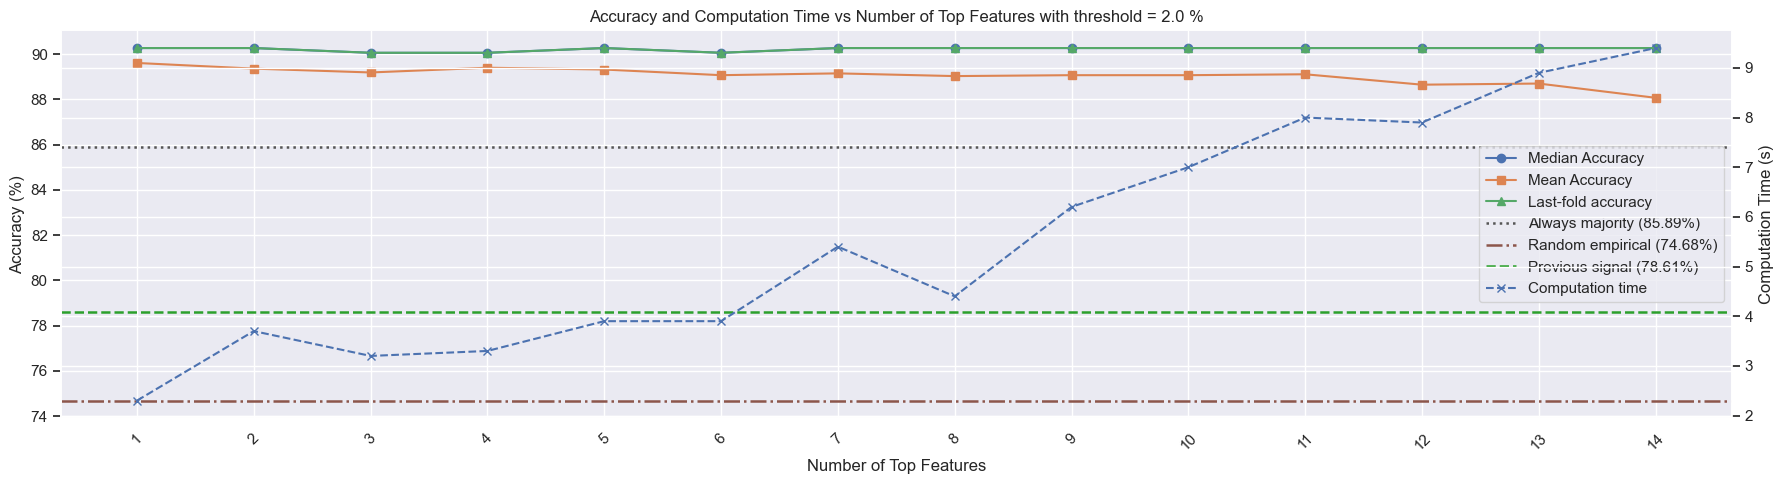

In [361]:
# ==================================================
# Plot accuracy + computation time (dual axis)
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="darkgrid")

# Data (categorical x-axis)
x = results_df.index.astype(str)
y_acc_median = results_df["Median accuracy (%)"]
y_acc_mean = results_df["Mean accuracy (%)"]
y_acc_last_fold = results_df["Last-fold accuracy (%)"]
y_time = results_df["Comp time (s)"]

# Create figure
fig, ax1 = plt.subplots(figsize=(18, 5))

# Left axis: accuracy
ax1.set_ylabel("Accuracy (%)")
ax1.set_xlabel("Number of Top Features")

line1, = ax1.plot(x, y_acc_median, marker='o', label="Median Accuracy")

line2, = ax1.plot(x, y_acc_mean, marker='s', label="Mean Accuracy")

line3, = ax1.plot(x, y_acc_last_fold, marker='^', label="Last-fold accuracy")

# Baseline reference strategies
baseline_lines = []
baseline_styles = {
    "Always majority": {"color": "#555555", "linestyle": ":"},
    "Random empirical": {"color": "#8c564b", "linestyle": "-."},
    "Previous signal": {"color": "#2ca02c", "linestyle": "--"},
}

for baseline_name, style in baseline_styles.items():
    baseline_acc = baseline_results_df.loc[baseline_name, "Accuracy (%)"]
    baseline_lines.append(
        ax1.axhline(
            baseline_acc,
            linewidth=1.8,
            label=f"{baseline_name} ({baseline_acc:.2f}%)",
            **style,
        )
    )

# Right axis: computation time
ax2 = ax1.twinx()
ax2.set_ylabel("Computation Time (s)")

line4, = ax2.plot(x, y_time, linestyle='--', marker='x', label="Computation time")

# Combined legend
lines = [line1, line2, line3, *baseline_lines, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

# Title and formatting
plt.title("Accuracy and Computation Time vs Number of Top Features with threshold = " + str(signal_threshold*100) + " %")
ax1.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
print("Accuracy and computation time for threshold =", signal_threshold*100, "%")
plt.show()

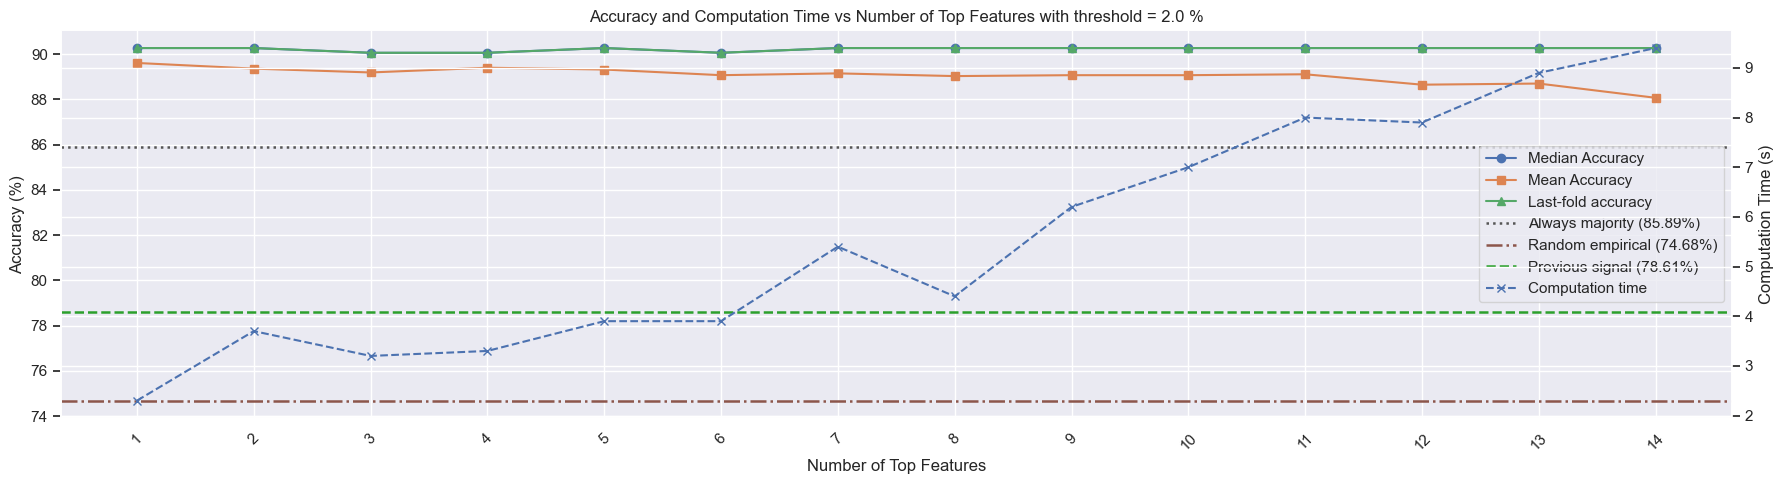

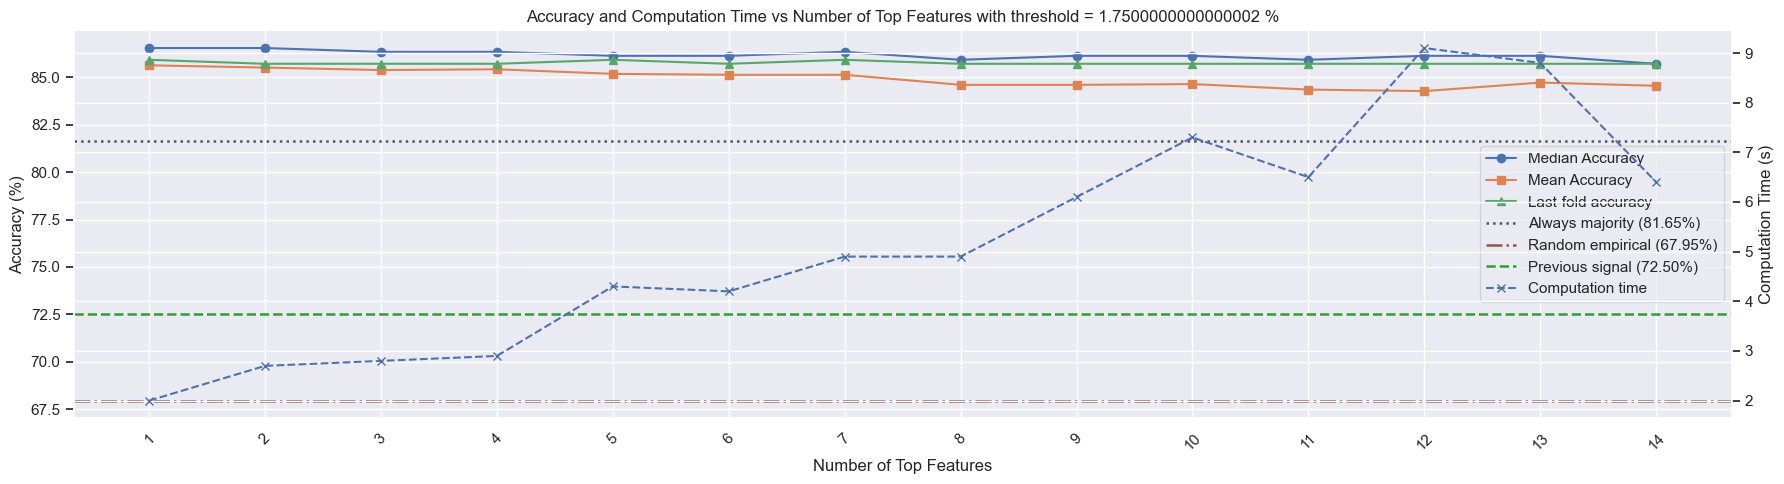

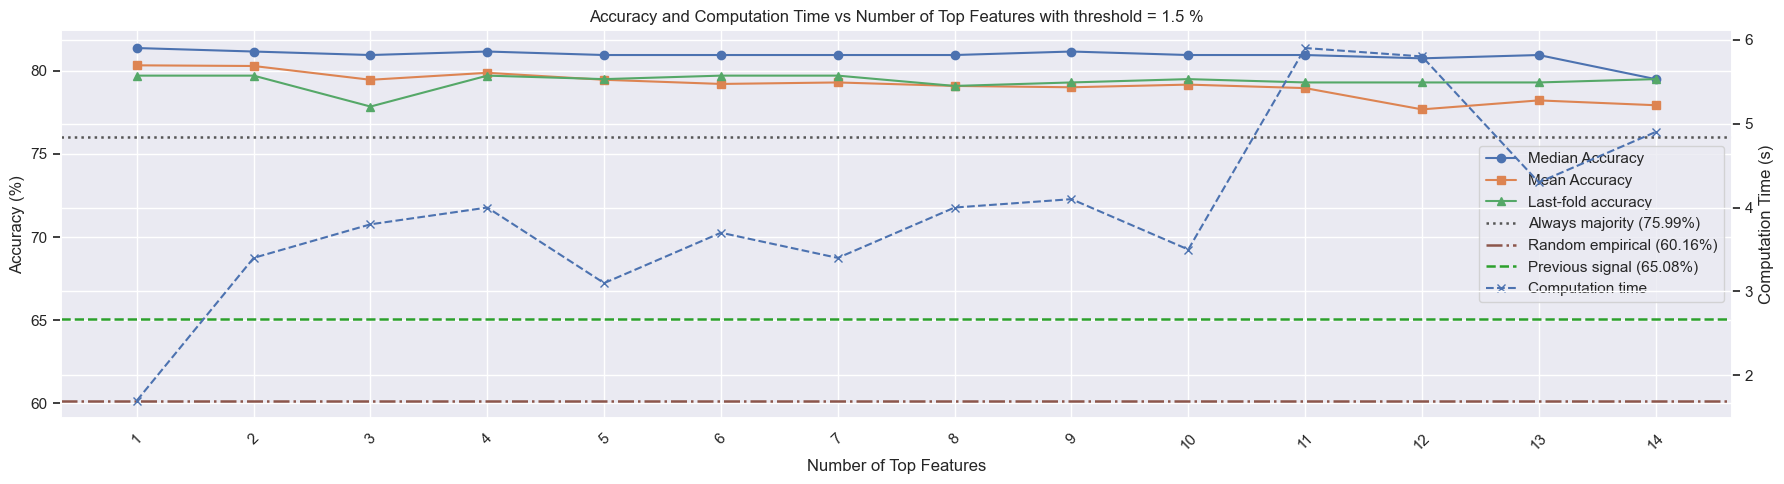

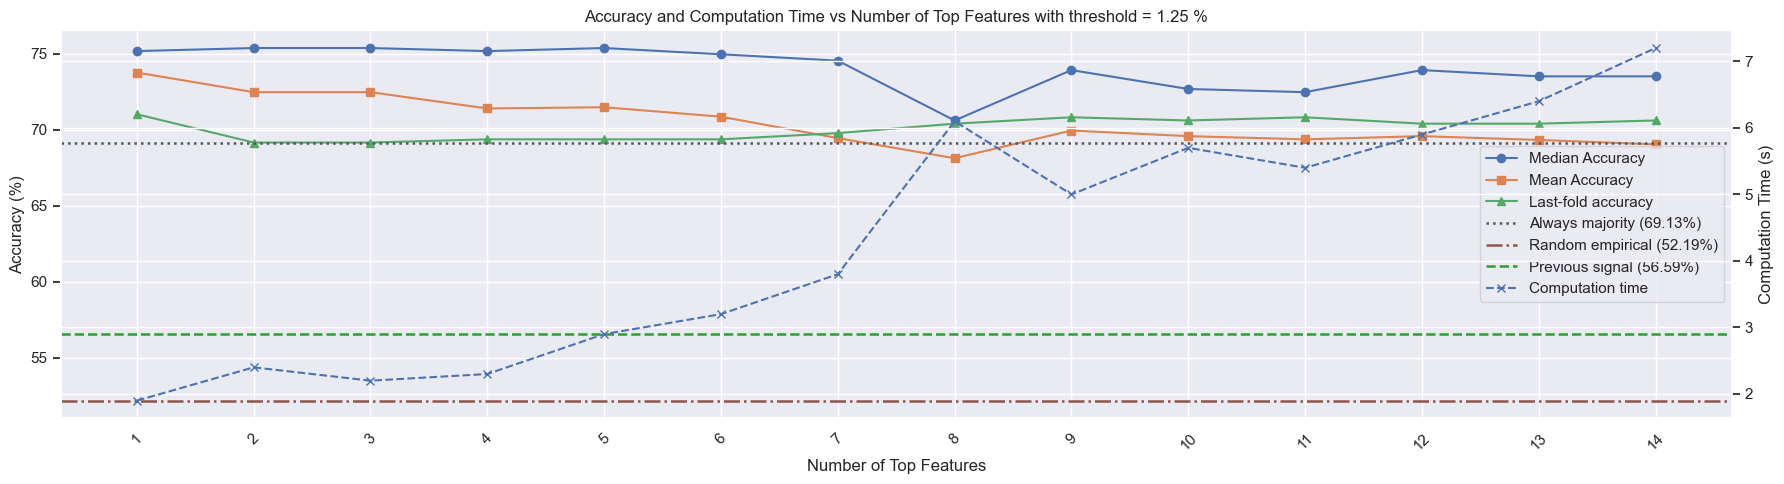

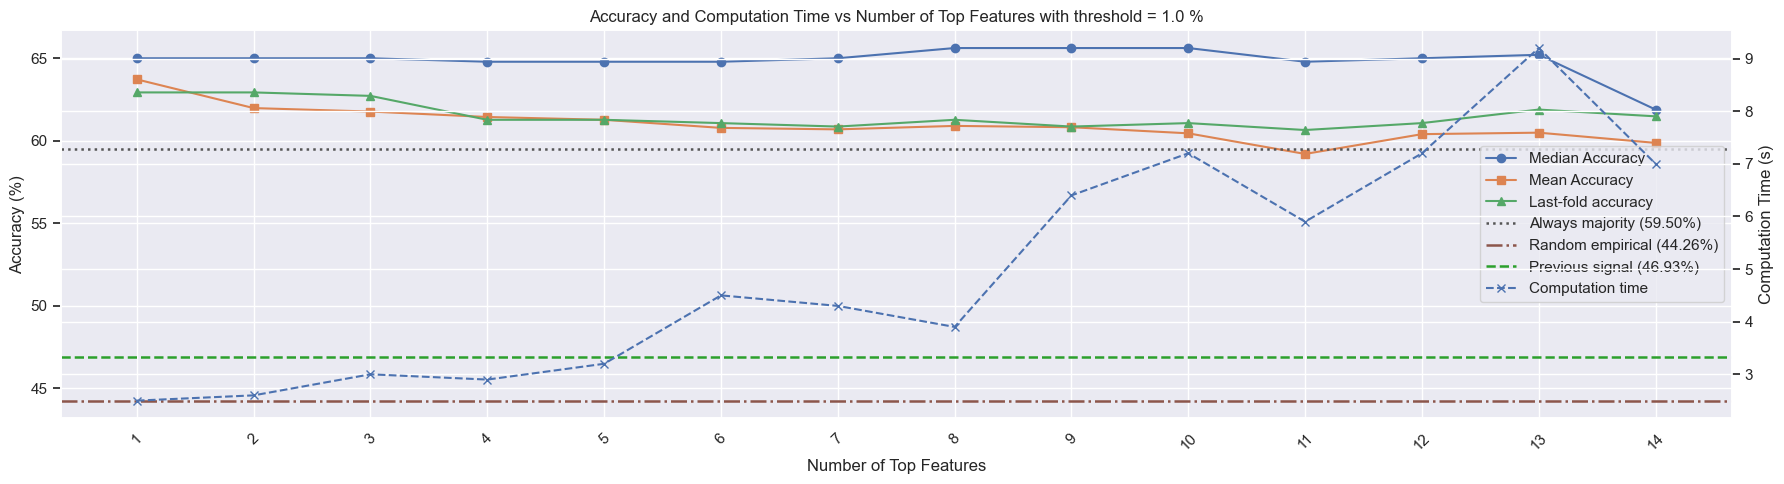

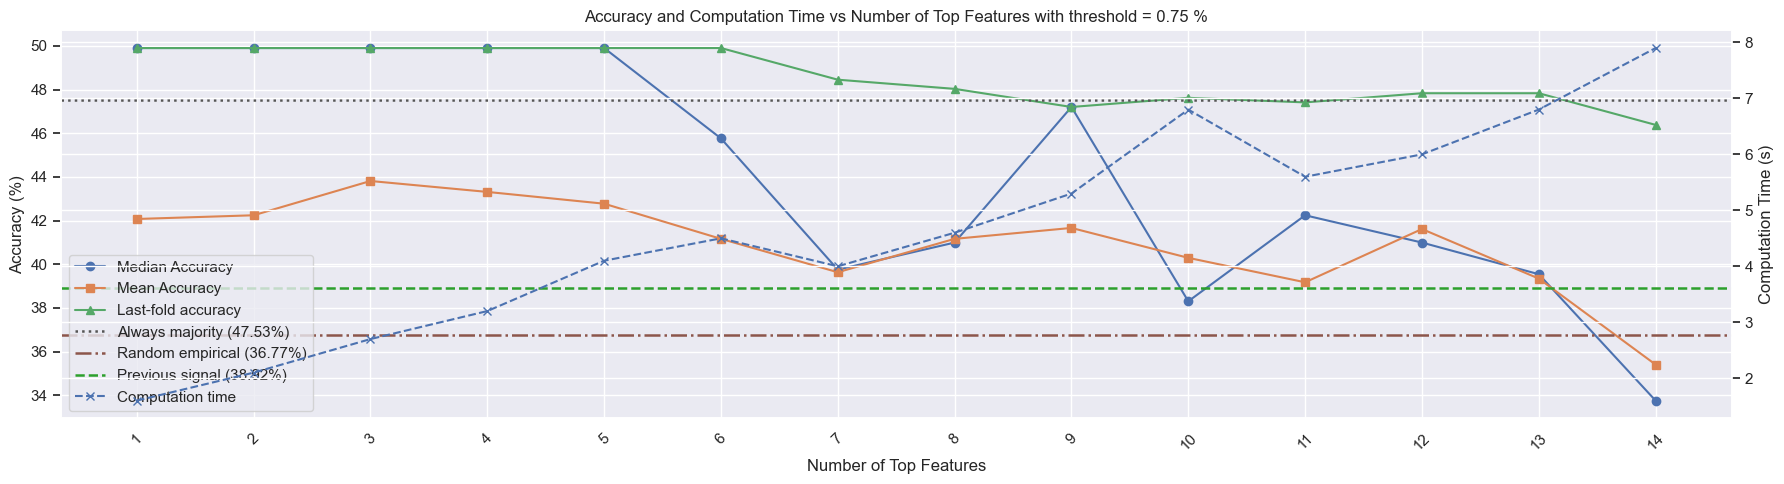

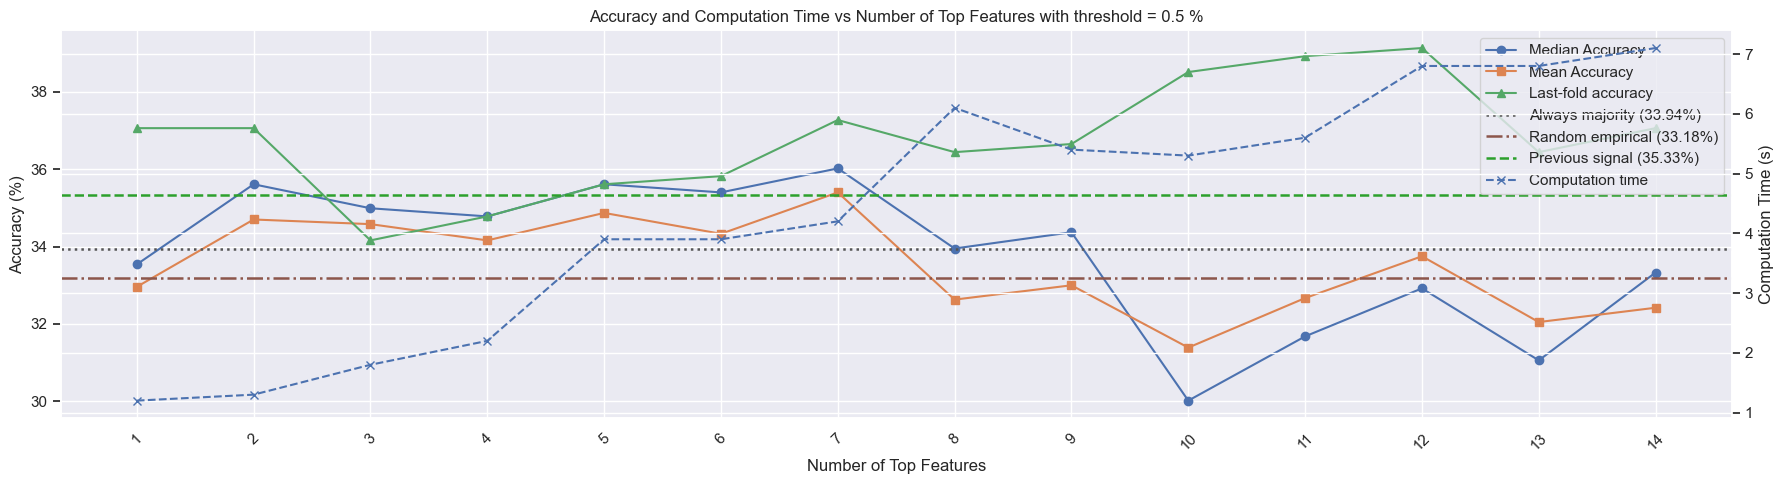

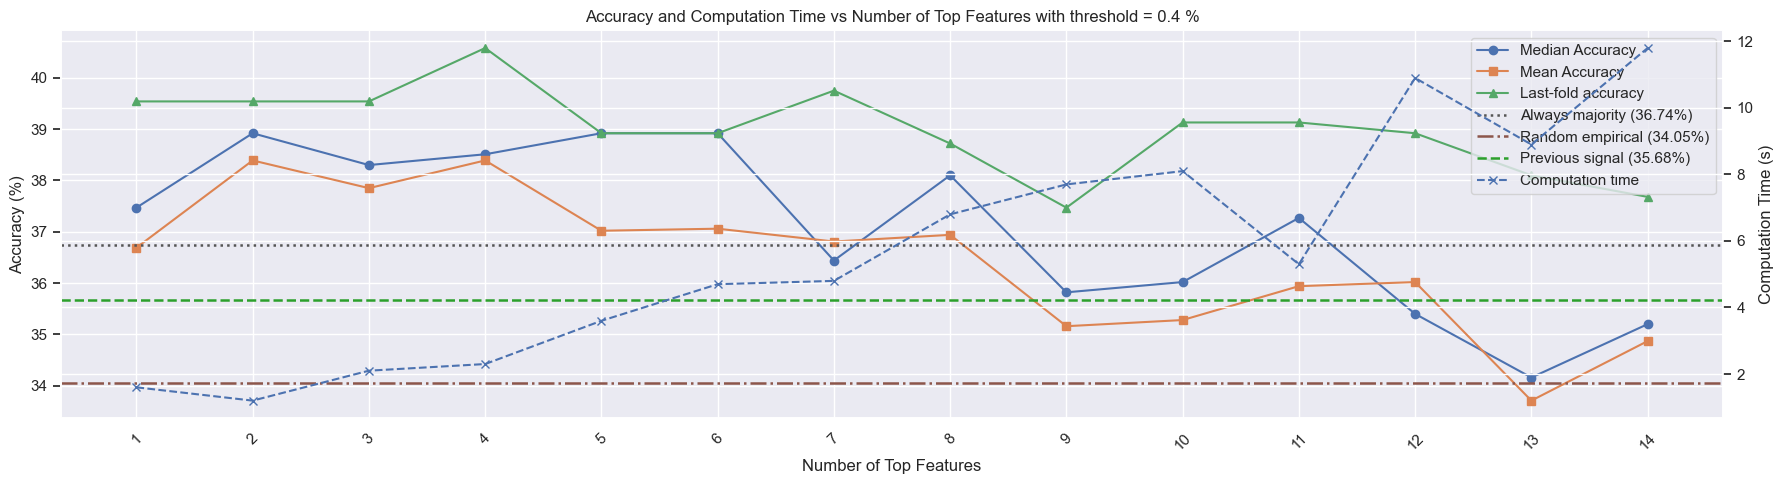

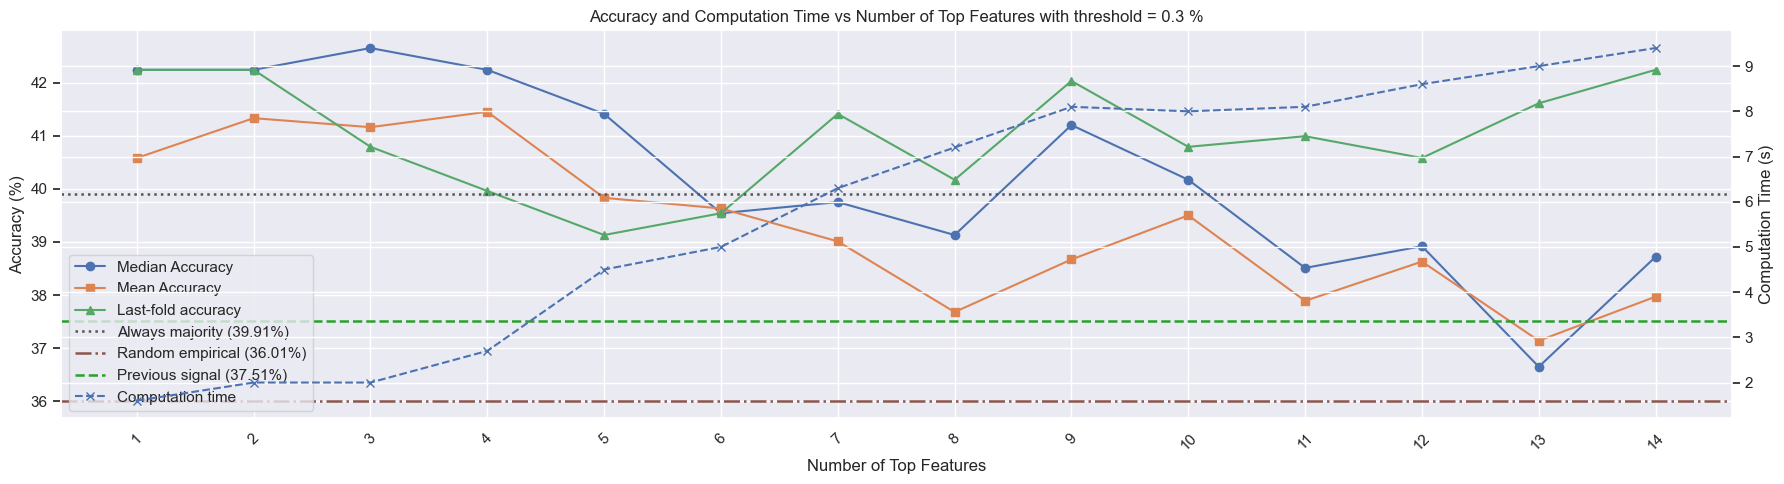

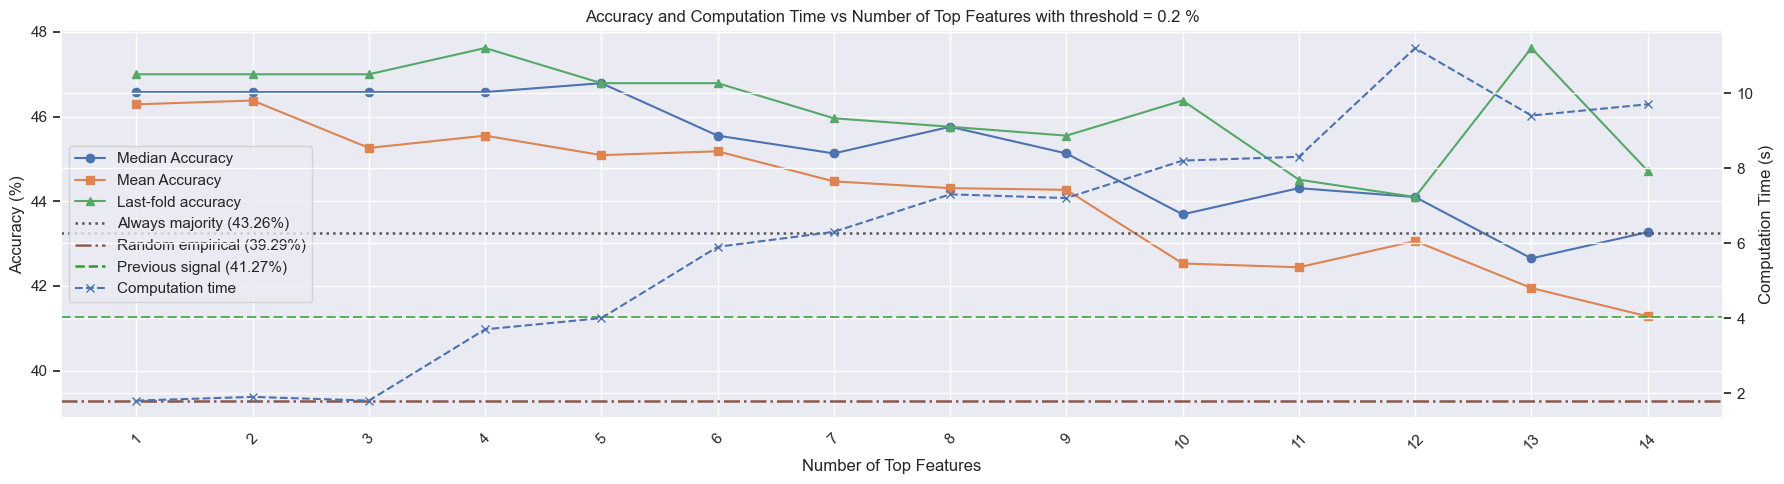

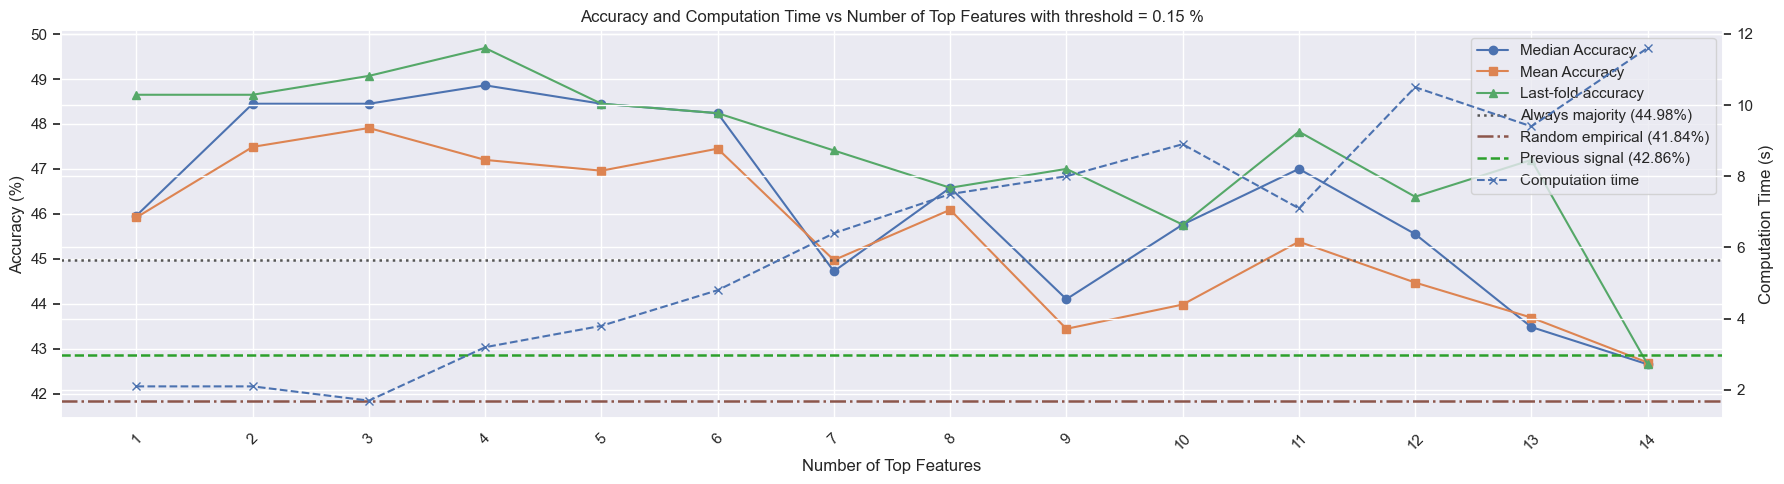

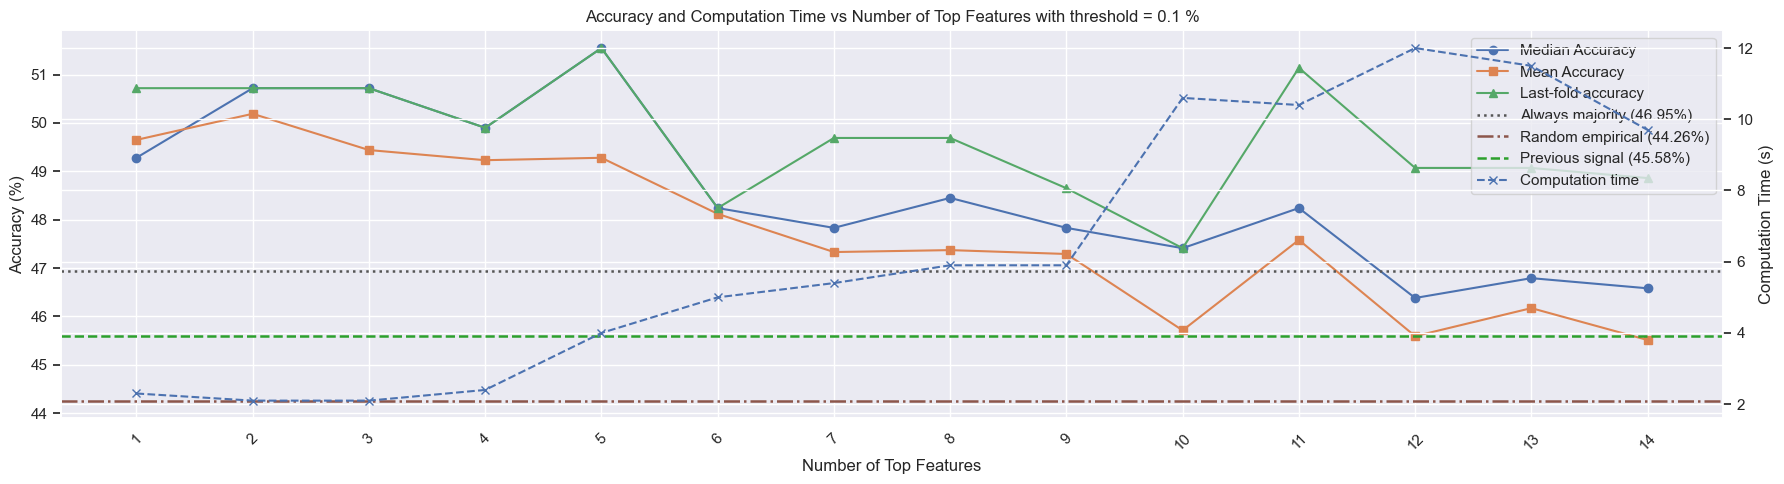

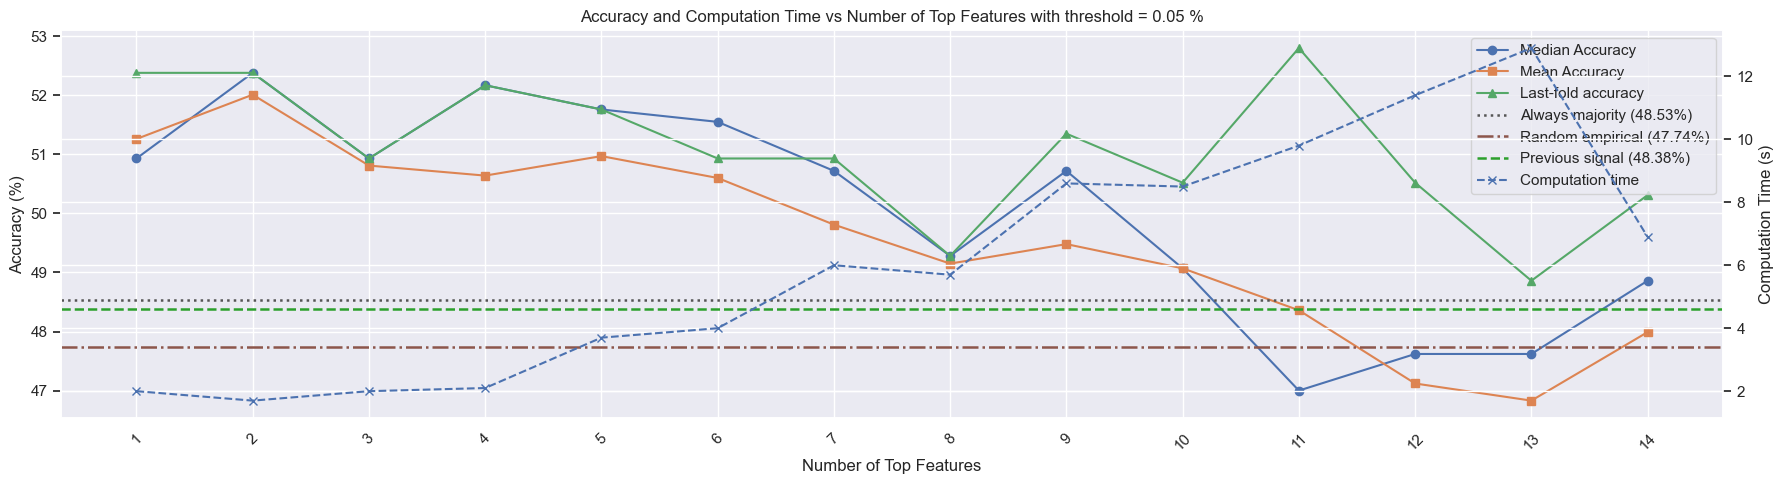

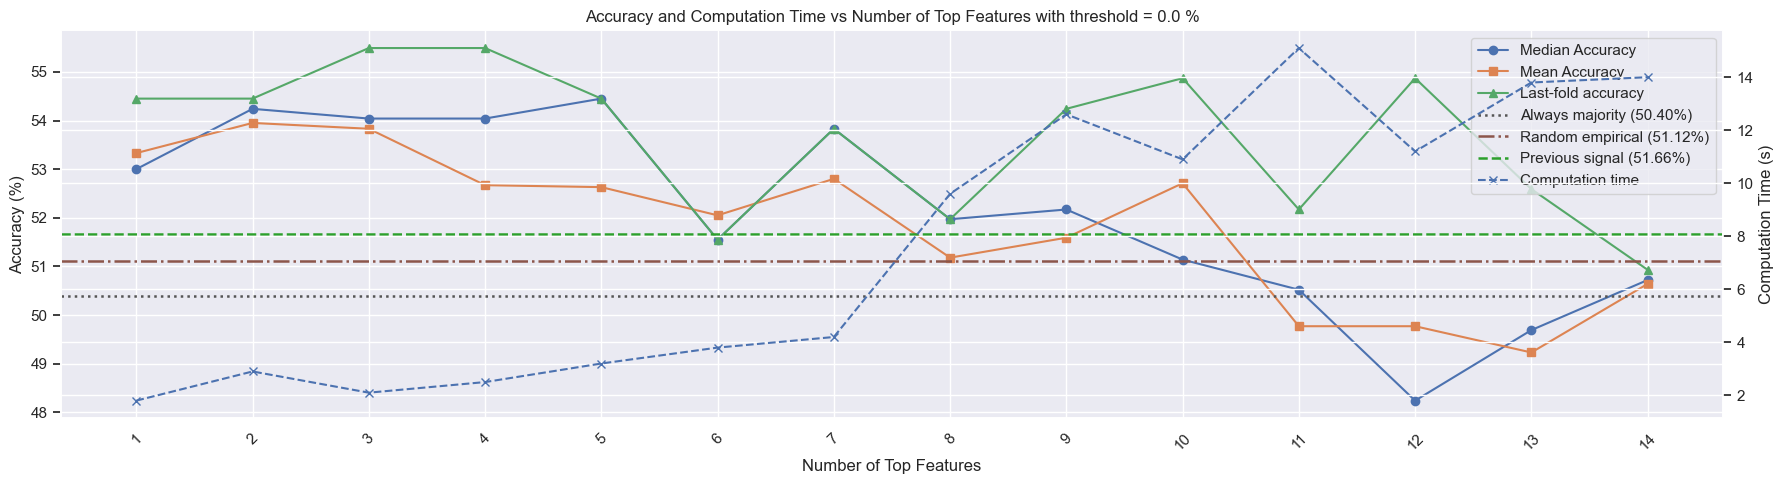

By analysing the results, we can see that

In [362]:
# ==================================================
# Feature selection frequency across CV folds
# ==================================================

# Find n_features with highest median accuracy
best_n = results_df["Median accuracy (%)"].idxmax()
best_acc = results_df.loc[best_n, "Median accuracy (%)"]

# Rebuild target explicitly and align it to X
target = df["Signal"].loc[X.index]

# Make sure these are the same as used in run_mlp_for_top_n earlier
random_state = 42
# number_of_folds = 10

# Same CV split used in run_mlp_for_top_n
# kf = KFold(n_splits=number_of_folds, shuffle=True, random_state=random_state)
tscv = TimeSeriesSplit(n_splits=number_of_folds)

# Store selected features and their fold-level mutual-information scores
selected_feature_records = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

    # Training data for this fold only
    X_train = X.iloc[train_idx]
    y_train = target.iloc[train_idx]

    # Same preprocessing + selector as in the pipeline
    selector_pipe = Pipeline([
        ("variance_filter", VarianceThreshold(threshold=0.0)),
        ("scaler", MinMaxScaler()),
        # ("selector", SelectKBest(score_func=f_classif, k=best_n))
        # ("selector", SelectKBest(score_func=mutual_info_classif, k=best_n))
        ("selector", SelectKBest(score_func=pearson_score, k=best_n)),

    ])

    # Fit only on the training fold
    selector_pipe.fit(X_train, y_train)

    # Extract selected feature names and mutual-information scores
    variance_filter = selector_pipe.named_steps["variance_filter"]
    selector = selector_pipe.named_steps["selector"]

    features_after_variance = X.columns[variance_filter.get_support()]
    selected_mask = selector.get_support()

    selected_features = features_after_variance[selected_mask]
    selected_scores = selector.scores_[selected_mask]

    # Save selected features and scores
    for feature, score in zip(selected_features, selected_scores):
        selected_feature_records.append({
            "Fold": fold,
            "Feature": feature,
            "Absolute Pearson correlation": score
        })

# Count how often each feature was selected and average its mutual-information score
feature_frequency_df = (
    pd.DataFrame(selected_feature_records)
    .groupby("Feature", as_index=False)
    .agg(
        **{
            "Selection count": ("Feature", "count"),
            "Mean absolute Pearson correlation": ("Absolute Pearson correlation", "mean")
        }
    )
)

# Add frequency as percentage of folds
feature_frequency_df["Selection frequency (%)"] = (
    100 * feature_frequency_df["Selection count"] / tscv.get_n_splits()
)

# Sort by selection count, then by mean mutual-information scores
feature_frequency_df = (
    feature_frequency_df
    .sort_values(
        ["Selection count", "Mean absolute Pearson correlation"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# Count fully stable and partially selected features
n_selected_all_folds = (feature_frequency_df["Selection count"] == tscv.get_n_splits()).sum()
n_selected_partial = (feature_frequency_df["Selection count"] < tscv.get_n_splits()).sum()

# Output
print("\n", f"Best number of features: {best_n}")
print(f"Median accuracy: {best_acc:.2f} %")
print(f"Features selected in all folds: {n_selected_all_folds}")
print(f"Features selected only partially: {n_selected_partial}")

print(
    "\nFeature selection frequency across CV folds:"
    "\nCaveat: this table shows how often each feature was selected across folds. "
    "The mutual-information score shown is the average absolute Pearson correlation across the folds "
    "where that feature was selected, not an MLP feature importance.\n"
)

display(feature_frequency_df)


 Best number of features: 1
Median accuracy: 90.27 %
Features selected in all folds: 0
Features selected only partially: 3

Feature selection frequency across CV folds:
Caveat: this table shows how often each feature was selected across folds. The mutual-information score shown is the average absolute Pearson correlation across the folds where that feature was selected, not an MLP feature importance.



,Feature,Selection count,Mean absolute Pearson correlation,Selection frequency (%)
0,TANH,3,0.078018,60.0
1,EOM_14_100000000,1,0.123114,20.0
2,CDL_STICKSANDWICH,1,0.089710,20.0
